<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

In [ ]:
import site
import shutil
from pathlib import Path

user_site = Path(site.getusersitepackages())
targets = [user_site / "sklearn"] + list(user_site.glob("scikit_learn-*.dist-info"))

for p in targets:
    if p.exists():
        if p.is_dir():
            shutil.rmtree(p, ignore_errors=True)
        else:
            p.unlink(missing_ok=True)

print("Removidos artefatos antigos do scikit-learn em:", user_site)
%pip install -q --upgrade pip setuptools wheel
%pip install -q --upgrade --no-cache-dir --only-binary=:all: numpy scipy joblib threadpoolctl
%pip install -q --upgrade --no-cache-dir --only-binary=:all: scikit-learn==1.5.2

Removidos artefatos antigos do scikit-learn em: C:\Users\SAMSUNG\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from collections import Counter

# Carrega o dataset Iris
iris = load_iris()
X, y = iris.data, iris.target

# Divide os dados em treino e teste de forma estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"Tamanho treino: {X_train.shape[0]} amostras")
print(f"Tamanho teste: {X_test.shape[0]} amostras")
print("Distribuicao no y (treino):", Counter(y_train))
print("Distribuicao no y (teste):", Counter(y_test))

Tamanho treino: 105 amostras
Tamanho teste: 45 amostras
Distribuicao no y (treino): Counter({np.int64(1): 35, np.int64(0): 35, np.int64(2): 35})
Distribuicao no y (teste): Counter({np.int64(2): 15, np.int64(1): 15, np.int64(0): 15})


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Treina a arvore com parametros padrao
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predicoes e metricas
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Acuracia no treino: {train_acc:.4f}")
print(f"Acuracia no teste:  {test_acc:.4f}")

Acuracia no treino: 1.0000
Acuracia no teste:  0.9333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

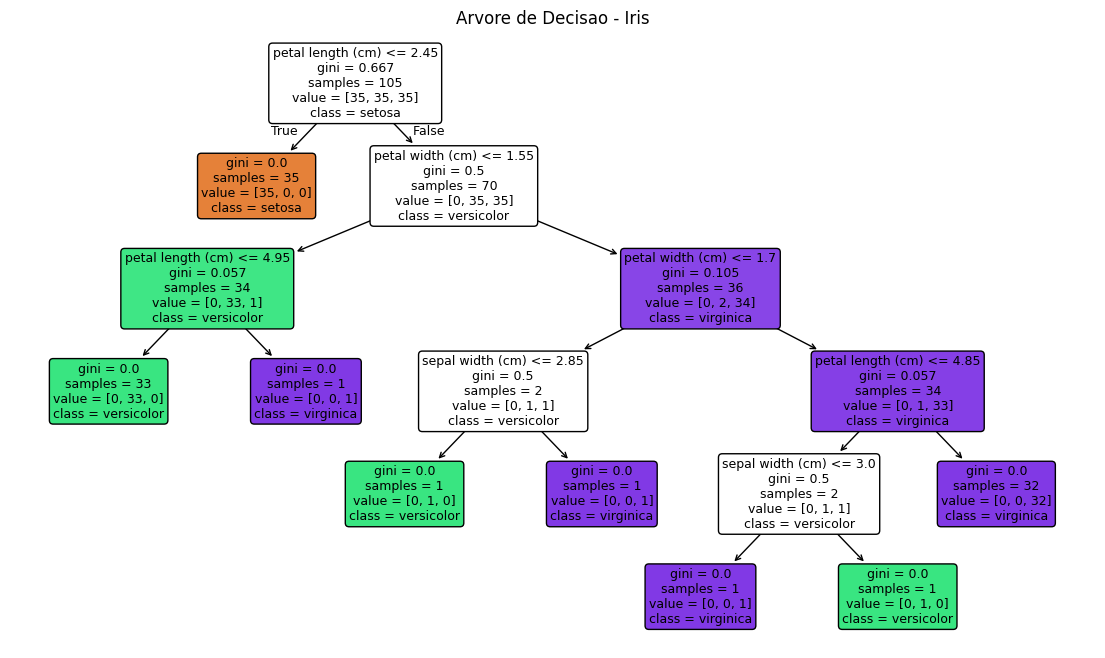

Atributo na raiz: petal length (cm)
Profundidade da arvore: 5


In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 8))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Arvore de Decisao - Iris")
plt.show()

root_feature = iris.feature_names[clf.tree_.feature[0]]
tree_depth = clf.get_depth()

print("Atributo na raiz:", root_feature)
print("Profundidade da arvore:", tree_depth)

Com base na saida da celula anterior:
- O atributo na raiz e o exibido em `Atributo na raiz` (obtido por `clf.tree_.feature[0]`).
- A profundidade da arvore e o valor exibido em `Profundidade da arvore` (obtido por `clf.get_depth()`).

A visualizacao com `plot_tree()` confirma essa estrutura de decisoes.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [7]:
import pandas as pd

depth_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, None]
results = []

for d in depth_values:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc_d = accuracy_score(y_train, model.predict(X_train))
    test_acc_d = accuracy_score(y_test, model.predict(X_test))

    results.append({
        "max_depth": d,
        "acuracia_treino": train_acc_d,
        "acuracia_teste": test_acc_d,
        "profundidade_arvore": model.get_depth(),
        "num_folhas": model.get_n_leaves(),
        "gap_treino_teste": train_acc_d - test_acc_d
    })

df_depth = pd.DataFrame(results)
df_depth

,max_depth,acuracia_treino,acuracia_teste,profundidade_arvore,num_folhas,gap_treino_teste
0,1.0,0.666667,0.666667,1,2,0.000000
1,2.0,0.971429,0.888889,2,3,0.082540
2,3.0,0.980952,0.977778,3,5,0.003175
3,4.0,0.990476,0.888889,4,7,0.101587
4,5.0,1.000000,0.933333,5,8,0.066667
5,6.0,1.000000,0.933333,5,8,0.066667
6,7.0,1.000000,0.933333,5,8,0.066667
7,8.0,1.000000,0.933333,5,8,0.066667
8,9.0,1.000000,0.933333,5,8,0.066667
9,NaN,1.000000,0.933333,5,8,0.066667


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

Com base na tabela (`df_depth`):
- O overfitting comeca quando a acuracia de treino continua subindo (ou fica muito alta) e a acuracia de teste para de melhorar, aumentando o gap treino-teste.
- Quando `max_depth=None`, a arvore nao tem limite de profundidade e pode criar divisoes ate memorizar os exemplos de treino. Por isso ela pode atingir 100% no treino, mas isso nao garante melhor generalizacao no teste.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [6]:
criteria = ["gini", "entropy"]
rows_crit = []

for c in criteria:
    model_c = DecisionTreeClassifier(criterion=c, random_state=42)
    model_c.fit(X_train, y_train)

    rows_crit.append({
        "criterion": c,
        "profundidade": model_c.get_depth(),
        "acuracia_treino": accuracy_score(y_train, model_c.predict(X_train)),
        "acuracia_teste": accuracy_score(y_test, model_c.predict(X_test))
    })

df_crit = pd.DataFrame(rows_crit)
df_crit

,criterion,profundidade,acuracia_treino,acuracia_teste
0,gini,5,1.0,0.933333
1,entropy,6,1.0,0.888889


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [8]:
# Investigacao do impacto de min_samples_leaf
candidate_values = [1, 2, 3, 4, 5, 6, 8, 10, 12]
rows_leaf = []

for leaf in candidate_values:
    model_leaf = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        random_state=42
    )
    model_leaf.fit(X_train, y_train)

    train_leaf = accuracy_score(y_train, model_leaf.predict(X_train))
    test_leaf = accuracy_score(y_test, model_leaf.predict(X_test))

    rows_leaf.append({
        "min_samples_leaf": leaf,
        "acuracia_treino": train_leaf,
        "acuracia_teste": test_leaf,
        "profundidade": model_leaf.get_depth(),
        "num_folhas": model_leaf.get_n_leaves()
    })

df_leaf = pd.DataFrame(rows_leaf).sort_values(
    by="acuracia_teste", ascending=False
).reset_index(drop=True)

best_model_params = df_leaf.iloc[0]
df_leaf

,min_samples_leaf,acuracia_treino,acuracia_teste,profundidade,num_folhas
0,1,1.000000,0.933333,5,8
1,2,0.971429,0.888889,4,6
2,4,0.971429,0.888889,4,6
3,5,0.971429,0.888889,3,5
4,6,0.971429,0.888889,3,5
5,10,0.971429,0.888889,3,5
6,8,0.971429,0.888889,3,5
7,12,0.971429,0.888889,3,5
8,3,0.980952,0.844444,4,6


Nesta analise, o hiperparametro investigado foi `min_samples_leaf`.

Melhor modelo encontrado (maior acuracia de teste na tabela `df_leaf`):
- `min_samples_leaf = 1`
- acuracia no treino: `1.0000`
- acuracia no teste: `0.9333`
- profundidade: `5`
- numero de folhas: `8`

Interpretacao: valores menores de `min_samples_leaf` deixam a arvore mais flexivel, aumentando desempenho no treino. Conforme esse valor cresce, a arvore simplifica (menos profundidade/folhas), o que pode reduzir overfitting, mas tambem pode reduzir acuracia de teste dependendo do ponto.